In [4]:
import pandas as pd
import numpy as np

In [5]:
# carregando o dataset
df_principal = pd.read_csv('netflix_large_dataset_cleaned.csv')
display(df_principal)
display(df_principal.describe())
display(df_principal.info())

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score
0,U100000,21,Female,Canada,North America,Basic,8.99,2022-03-01,2022-04-19 00:00:00,Bank Transfer,...,2,100,2022-05-23,Night,5,Yes,Trending,54,156,0.35
1,U100001,17,Female,Nigeria,Africa,Basic,8.99,2022-12-02,2026-02-07,Bank Transfer,...,1,86,2023-03-29,Evening,3,No,Trending,55,150,0.49
2,U100002,60,Male,Nigeria,Africa,Standard,13.99,2023-09-01,2026-02-07,Card,...,3,100,2023-09-15,Evening,3,No,Friend,10,245,0.28
3,U100003,60,Male,Nigeria,Africa,Standard,13.99,2024-05-26,2026-02-07,Card,...,3,100,2025-01-31,Afternoon,3,No,Trending,54,285,0.73
4,U100004,50,Female,Canada,North America,Basic,8.99,2023-12-19,2026-02-07,Bank Transfer,...,2,100,2024-06-17,Afternoon,4,Yes,Algorithm,8,139,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U149995,40,Female,UK,Europe,Basic,8.99,2022-03-29,2023-05-09 00:00:00,Bank Transfer,...,1,91,2022-06-01,Night,3,No,Algorithm,25,196,0.54
49996,U149996,17,Male,USA,North America,Standard,13.99,2022-07-20,2026-02-07,Card,...,2,92,2022-12-31,Afternoon,2,No,Search,24,241,0.93
49997,U149997,17,Male,Brazil,South America,Standard,13.99,2024-06-07,2026-02-07,Card,...,3,100,2024-08-05,Night,3,No,Ads,4,272,0.58
49998,U149998,21,Female,South Africa,Africa,Premium,17.99,2023-02-05,2026-02-07,Card,...,4,100,2023-09-11,Afternoon,4,Yes,Search,38,341,0.86


,age_group,monthly_fee,release_year,watch_time_minutes,session_count,completion_percentage,rating,days_since_last_watch,avg_weekly_watch_time,content_diversity_score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,36.412180,12.990900,2011.534020,84.999620,2.358740,91.915480,3.417980,29.938080,256.341400,0.601056
std,15.313068,3.610202,6.963695,28.086897,0.966408,11.953255,1.015861,17.621492,81.632833,0.230076
min,17.000000,8.990000,2000.000000,10.000000,1.000000,20.000000,1.000000,0.000000,33.000000,0.200000
25%,21.000000,8.990000,2006.000000,63.000000,2.000000,87.000000,3.000000,15.000000,191.000000,0.400000
50%,40.000000,13.990000,2011.000000,83.000000,2.000000,99.000000,3.000000,30.000000,251.000000,0.600000
75%,50.000000,17.990000,2018.000000,106.000000,3.000000,100.000000,4.000000,45.000000,318.250000,0.800000
max,60.000000,17.990000,2025.000000,180.000000,6.000000,100.000000,5.000000,60.000000,499.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  50000 non-null  str    
 1   age_group                50000 non-null  int64  
 2   gender                   50000 non-null  str    
 3   country                  50000 non-null  str    
 4   region                   50000 non-null  str    
 5   subscription_plan        50000 non-null  str    
 6   monthly_fee              50000 non-null  float64
 7   subscription_start_date  50000 non-null  str    
 8   subscription_end_date    50000 non-null  str    
 9   payment_method           50000 non-null  str    
 10  discount_applied         50000 non-null  str    
 11  churn_status             50000 non-null  str    
 12  title                    50000 non-null  str    
 13  content_type             50000 non-null  str    
 14  genre                    50000 no

None

In [6]:
# limpeza e tratamento dos dados
df_principal = df_principal.drop_duplicates(subset=['user_id', 'subscription_start_date'])

df_principal['subscription_start_date'] = pd.to_datetime(
    df_principal['subscription_start_date'], format='%Y-%m-%d', errors='coerce'
)
df_principal['subscription_end_date'] = pd.to_datetime(
    df_principal['subscription_end_date'], format='mixed', errors='coerce'
)
df_principal['date_watched'] = pd.to_datetime(
    df_principal['date_watched'], format='%Y-%m-%d', errors='coerce'
)

colunas_texto = [
    'gender', 'country', 'region', 'subscription_plan', 'payment_method',
    'time_of_day', 'liked', 'recommendation_source'
]
df_principal[colunas_texto] = df_principal[colunas_texto].apply(lambda col: col.str.strip().str.title())

display(df_principal)
display(df_principal.info())

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score
0,U100000,21,Female,Canada,North America,Basic,8.99,2022-03-01,2022-04-19,Bank Transfer,...,2,100,2022-05-23,Night,5,Yes,Trending,54,156,0.35
1,U100001,17,Female,Nigeria,Africa,Basic,8.99,2022-12-02,2026-02-07,Bank Transfer,...,1,86,2023-03-29,Evening,3,No,Trending,55,150,0.49
2,U100002,60,Male,Nigeria,Africa,Standard,13.99,2023-09-01,2026-02-07,Card,...,3,100,2023-09-15,Evening,3,No,Friend,10,245,0.28
3,U100003,60,Male,Nigeria,Africa,Standard,13.99,2024-05-26,2026-02-07,Card,...,3,100,2025-01-31,Afternoon,3,No,Trending,54,285,0.73
4,U100004,50,Female,Canada,North America,Basic,8.99,2023-12-19,2026-02-07,Bank Transfer,...,2,100,2024-06-17,Afternoon,4,Yes,Algorithm,8,139,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U149995,40,Female,Uk,Europe,Basic,8.99,2022-03-29,2023-05-09,Bank Transfer,...,1,91,2022-06-01,Night,3,No,Algorithm,25,196,0.54
49996,U149996,17,Male,Usa,North America,Standard,13.99,2022-07-20,2026-02-07,Card,...,2,92,2022-12-31,Afternoon,2,No,Search,24,241,0.93
49997,U149997,17,Male,Brazil,South America,Standard,13.99,2024-06-07,2026-02-07,Card,...,3,100,2024-08-05,Night,3,No,Ads,4,272,0.58
49998,U149998,21,Female,South Africa,Africa,Premium,17.99,2023-02-05,2026-02-07,Card,...,4,100,2023-09-11,Afternoon,4,Yes,Search,38,341,0.86


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  50000 non-null  str           
 1   age_group                50000 non-null  int64         
 2   gender                   50000 non-null  str           
 3   country                  50000 non-null  str           
 4   region                   50000 non-null  str           
 5   subscription_plan        50000 non-null  str           
 6   monthly_fee              50000 non-null  float64       
 7   subscription_start_date  50000 non-null  datetime64[us]
 8   subscription_end_date    50000 non-null  datetime64[us]
 9   payment_method           50000 non-null  str           
 10  discount_applied         50000 non-null  str           
 11  churn_status             50000 non-null  str           
 12  title                    50000 non-null  st

None

In [11]:
# criação de novas colunas e tradução das existentes

titulos_trad = {
    'user_id': 'user_id',
'age_group': 'idade',
'gender': 'genero',
'country': 'país',
'region': 'regiao',
'subscription_plan': 'tipo_de_plano',
'monthly_fee': 'mensalidade',
'subscription_start_date': 'data_inicio_assinatura',
'subscription_end_date': 'data_fim_assinatura',
'payment_method': 'metodo_pagamento',
'discount_applied': 'desconto_aplicado',
'churn_status': 'status_cancelamento',
'title': 'titulo',
'content_type': 'tipo_conteudo',
'genre': 'genero_conteudo',
'language': 'idioma',
'release_year': 'data_lancamento',
'device_type': 'aparelho',
'watch_time_minutes': 'tempo_assistido',
'session_count': 'qtd_sessoes',
'completion_percentage': 'porcentagem_assistida',
'date_watched': 'data_assistida',
'time_of_day': 'hora_do_dia',
'rating': 'avaliacao',
'liked': 'gostou',
'recommendation_source': 'fonte_recomendacao',
'days_since_last_watch': 'dias_desde_viu',
'avg_weekly_watch_time': 'tempo_medio_semanal',
'content_diversity_score': 'nota_diversidade_conteudo'
}

df_traduzido = df_principal.rename(columns=titulos_trad)

genero_trad = {'Female': 'Feminino', 'Male': 'Masculino'}
df_traduzido['genero'] = df_traduzido['genero'].map(genero_trad)

pais_trad = {'Canada': 'Canada',
'Nigeria': 'Nigeria',
'South Africa': 'Africa do Sul',
'Usa': 'EUA',
'France': 'França',
'Brazil': 'Brasil',
'Japan': 'Japao',
'Germany': 'Alemanha',
'India': 'India',
'Uk': 'Reino Unido'}
df_traduzido['país'] = df_traduzido['país'].map(pais_trad)

plano_trad = {'Basic': 'Basico', 'Standard': 'Padrao', 'Premium': 'Premium'}
df_traduzido['tipo_de_plano'] = df_traduzido['tipo_de_plano'].map(plano_trad)


pag_trad = {'Bank Transfer': 'Pix', 'Card': 'Cartao', 'Wallet': 'Carteira Digital'}
df_traduzido['metodo_pagamento'] = df_traduzido['metodo_pagamento'].map(pag_trad)

cancelamento_trad = {'Cancelled': 'Cancelado', 'Active': 'Ativo'}
df_traduzido['status_cancelamento'] = df_traduzido['status_cancelamento'].map(cancelamento_trad)

tipo_trad = {'Series': 'Serie', 'Movie': 'Filme'}
df_traduzido['tipo_conteudo'] = df_traduzido['tipo_conteudo'].map(tipo_trad)

gen_trad =  {'Romance': 'Romance',
'Comedy': 'Comedia',
'Thriller': 'Terror',
'Action': 'Acao',
'Drama': 'Drama',
'Animation': 'Animacao',
'Sci-Fi': 'Sci-Fi',
'Documentary': 'Documentario'}
df_traduzido['genero_conteudo'] = df_traduzido['genero_conteudo'].map(gen_trad)

idioma_trad = {'Hindi': 'Hindi',
'Portuguese': 'Portugues',
'German': 'Alemao',
'Japanese': 'Japones',
'French': 'Frances',
'English': 'Ingles',
'Yoruba': 'Ioruba'}
df_traduzido['idioma'] = df_traduzido['idioma'].map(idioma_trad)

gostou_trad = {'Yes': 'Sim', 'No': 'Nao'}
df_traduzido['gostou'] = df_traduzido['gostou'].map(gostou_trad)

fonte_trad = {'Trending': 'Trending',
'Friend': 'Amigo',
'Algorithm': 'Algoritmo',
'Ads': 'Anuncios',
'Search': 'Pesquisa'}
df_traduzido['fonte_recomendacao'] = df_traduzido['fonte_recomendacao'].map(fonte_trad)

hora_trad = {'Night': 'Fim da noite',
'Evening': 'Inicio da noite',
'Afternoon': 'Tarde',
'Morning': 'Manha'}
df_traduzido['hora_do_dia'] = df_traduzido['hora_do_dia'].map(hora_trad)

#coluna nova
df_traduzido['usuario_engajado'] = (
    (df_traduzido['tempo_assistido'] > df_traduzido['tempo_assistido'].median()) &
    (df_traduzido['qtd_sessoes'] > df_traduzido['qtd_sessoes'].median())
).astype(int)
df_traduzido['usuario_engajado'] = np.where(df_traduzido['usuario_engajado'] == 1, 'Sim', 'Nao')

display(df_traduzido)

,user_id,idade,genero,país,regiao,tipo_de_plano,mensalidade,data_inicio_assinatura,data_fim_assinatura,metodo_pagamento,...,porcentagem_assistida,data_assistida,hora_do_dia,avaliacao,gostou,fonte_recomendacao,dias_desde_viu,tempo_medio_semanal,nota_diversidade_conteudo,usuario_engajado
0,U100000,21,Feminino,Canada,North America,Basico,8.99,2022-03-01,2022-04-19,Pix,...,100,2022-05-23,Fim da noite,5,Sim,Trending,54,156,0.35,Nao
1,U100001,17,Feminino,Nigeria,Africa,Basico,8.99,2022-12-02,2026-02-07,Pix,...,86,2023-03-29,Inicio da noite,3,Nao,Trending,55,150,0.49,Nao
2,U100002,60,Masculino,Nigeria,Africa,Padrao,13.99,2023-09-01,2026-02-07,Cartao,...,100,2023-09-15,Inicio da noite,3,Nao,Amigo,10,245,0.28,Sim
3,U100003,60,Masculino,Nigeria,Africa,Padrao,13.99,2024-05-26,2026-02-07,Cartao,...,100,2025-01-31,Tarde,3,Nao,Trending,54,285,0.73,Sim
4,U100004,50,Feminino,Canada,North America,Basico,8.99,2023-12-19,2026-02-07,Pix,...,100,2024-06-17,Tarde,4,Sim,Algoritmo,8,139,0.42,Nao
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U149995,40,Feminino,Reino Unido,Europe,Basico,8.99,2022-03-29,2023-05-09,Pix,...,91,2022-06-01,Fim da noite,3,Nao,Algoritmo,25,196,0.54,Nao
49996,U149996,17,Masculino,EUA,North America,Padrao,13.99,2022-07-20,2026-02-07,Cartao,...,92,2022-12-31,Tarde,2,Nao,Pesquisa,24,241,0.93,Nao
49997,U149997,17,Masculino,Brasil,South America,Padrao,13.99,2024-06-07,2026-02-07,Cartao,...,100,2024-08-05,Fim da noite,3,Nao,Anuncios,4,272,0.58,Sim
49998,U149998,21,Feminino,Africa do Sul,Africa,Premium,17.99,2023-02-05,2026-02-07,Cartao,...,100,2023-09-11,Tarde,4,Sim,Pesquisa,38,341,0.86,Sim


In [48]:
#inicio das analises

#analises de tempo assistido

#tempo assistido por plano e dispositivo
df_tempo =  df_traduzido[['tempo_assistido', 'tipo_de_plano', 'aparelho']].groupby(by=['tipo_de_plano', 'aparelho']).mean().sort_values(by='tempo_assistido', ascending=False)
display(df_tempo)

#genero mais assistido filme e serie
df_genero =  df_traduzido[['tempo_assistido', 'genero_conteudo', 'tipo_conteudo']].groupby(by=['tipo_conteudo', 'genero_conteudo']).mean().sort_values(by=['tipo_conteudo','tempo_assistido'], ascending=False)
display(df_genero)

#tempo assistido por dispositivo
aparelho_tempo = df_traduzido.groupby('aparelho')['tempo_assistido'].mean().sort_values(ascending=False)
display(aparelho_tempo)

idade_tempo = df_traduzido.groupby('idade')['tempo_assistido'].mean().sort_values(ascending=False)
display(idade_tempo)

tempo_assistido
tipo_de_plano aparelho                 
Premium       TV             119.844516
              Tablet         119.551095
              Mobile         119.245447
              Laptop         119.095353
Padrao        Tablet          89.812281
              Laptop          89.510204
              Mobile          89.345146
              TV              89.183291
Basico        Tablet          59.858139
              Mobile          59.563072
              TV              59.555994
              Laptop          59.550508

tempo_assistido
tipo_conteudo genero_conteudo                 
Serie         Sci-Fi                 85.427895
              Drama                  85.200557
              Comedia                85.153937
              Animacao               85.126322
              Documentario           85.114354
              Romance                84.954201
              Terror                 84.471575
              Acao                   83.781753
Filme         Drama                  86.226429
              Sci-Fi                 85.317668
              Documentario           85.204061
              Romance                85.164309
              Animacao               84.907616
              Comedia                84.882104
              Terror                 84.674056
              Acao                   84.541545

aparelho
Tablet    86.014144
TV        85.050892
Laptop    84.938680
Mobile    84.560779
Name: tempo_assistido, dtype: float64

idade
40    85.235210
21    85.219127
50    85.217277
30    84.878989
17    84.756636
60    84.685516
Name: tempo_assistido, dtype: float64

In [44]:
#analise de cancelamento

cancelamento_perfil =  df_traduzido[['status_cancelamento', 'tipo_de_plano', 'usuario_engajado']].groupby(by=['tipo_de_plano', 'usuario_engajado', 'status_cancelamento']).value_counts()
display(cancelamento_perfil)

cancelamento_pais =  df_traduzido[['status_cancelamento', 'país']].groupby(by=['país']).value_counts()
display(cancelamento_pais)



tipo_de_plano  usuario_engajado  status_cancelamento
Basico         Nao               Ativo                  14619
                                 Cancelado               4952
               Sim               Ativo                    359
                                 Cancelado                101
Padrao         Nao               Ativo                   7443
                                 Cancelado               1330
               Sim               Ativo                   7371
                                 Cancelado               1275
Premium        Nao               Ativo                    253
                                 Cancelado                 29
               Sim               Ativo                  11346
                                 Cancelado                922
Name: count, dtype: int64

país           status_cancelamento
Africa do Sul  Ativo                  4203
               Cancelado               803
Alemanha       Ativo                  4108
               Cancelado               900
Brasil         Ativo                  4102
               Cancelado               829
Canada         Ativo                  4192
               Cancelado               885
EUA            Ativo                  4235
               Cancelado               860
França         Ativo                  4206
               Cancelado               858
India          Ativo                  4088
               Cancelado               875
Japao          Ativo                  4094
               Cancelado               859
Nigeria        Ativo                  4064
               Cancelado               873
Reino Unido    Ativo                  4099
               Cancelado               867
Name: count, dtype: int64

In [46]:
#tabela de cancelamento por pais com uma linha por pais

tabela_cancelamento_pais = df_principal[['country', 'churn_status']].copy()
tabela_cancelamento_pais['country'] = tabela_cancelamento_pais['country'].astype(str).str.split(',')
tabela_cancelamento_pais = tabela_cancelamento_pais.explode('country')
tabela_cancelamento_pais['country'] = tabela_cancelamento_pais['country'].str.strip()
tabela_cancelamento_pais = tabela_cancelamento_pais[tabela_cancelamento_pais['country'] != '']

tabela_cancelamento_pais['country'] = tabela_cancelamento_pais['country'].replace({**pais_trad, 'USA': 'EUA', 'UK': 'Reino Unido'})

tabela_cancelamento_pais = (
    tabela_cancelamento_pais
    .groupby(['country', 'churn_status'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={
        'Active': 'usuarios_ativos',
        'Cancelled': 'usuarios_cancelados'
    })
)

for coluna in ['usuarios_ativos', 'usuarios_cancelados']:
    if coluna not in tabela_cancelamento_pais.columns:
        tabela_cancelamento_pais[coluna] = 0

tabela_cancelamento_pais = tabela_cancelamento_pais[['usuarios_ativos', 'usuarios_cancelados']].reset_index()
tabela_cancelamento_pais = tabela_cancelamento_pais.rename(columns={'country': 'país'})
tabela_cancelamento_pais['diferenca'] = tabela_cancelamento_pais['usuarios_ativos'] - tabela_cancelamento_pais['usuarios_cancelados']
tabela_cancelamento_pais = tabela_cancelamento_pais.sort_values(by='diferenca', ascending=False)

display(tabela_cancelamento_pais)


churn_status,país,usuarios_ativos,usuarios_cancelados,diferenca
0,Africa do Sul,4203,803,3400
4,EUA,4235,860,3375
5,França,4206,858,3348
3,Canada,4192,885,3307
2,Brasil,4102,829,3273
7,Japao,4094,859,3235
9,Reino Unido,4099,867,3232
6,India,4088,875,3213
1,Alemanha,4108,900,3208
8,Nigeria,4064,873,3191


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

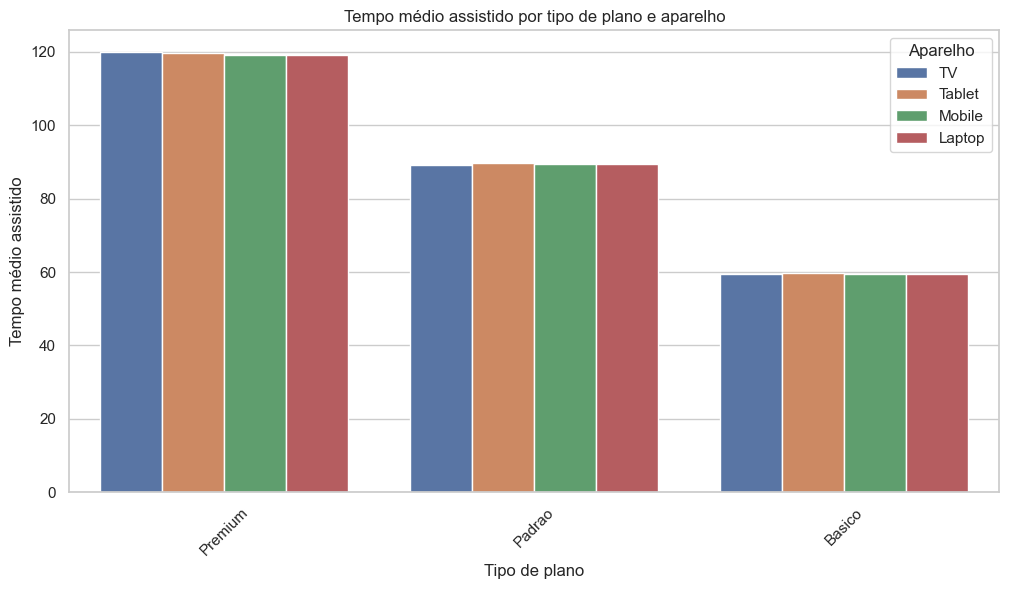

In [52]:
df_tempo_grafico = df_tempo.reset_index()

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_tempo_grafico,
    x='tipo_de_plano',
    y='tempo_assistido',
    hue='aparelho'
)

plt.title('Tempo médio assistido por tipo de plano e aparelho')
plt.xlabel('Tipo de plano')
plt.ylabel('Tempo médio assistido')
plt.xticks(rotation=45)
plt.legend(title='Aparelho')
plt.show()

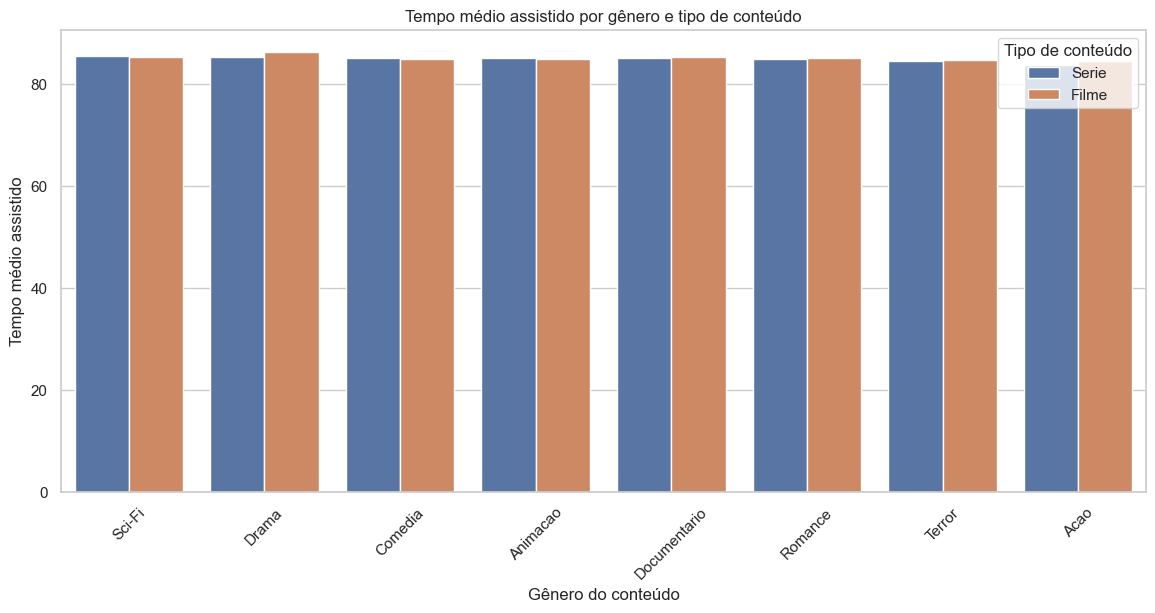

In [53]:
df_genero_grafico = df_genero.reset_index()

plt.figure(figsize=(14,6))
sns.barplot(
    data=df_genero_grafico,
    x='genero_conteudo',
    y='tempo_assistido',
    hue='tipo_conteudo'
)

plt.title('Tempo médio assistido por gênero e tipo de conteúdo')
plt.xlabel('Gênero do conteúdo')
plt.ylabel('Tempo médio assistido')
plt.xticks(rotation=45)
plt.legend(title='Tipo de conteúdo')
plt.show()

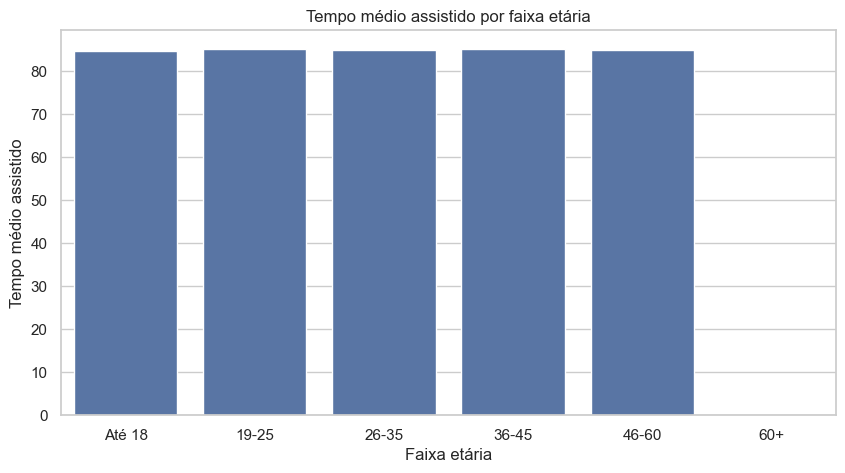

In [54]:
df_traduzido['faixa_idade'] = pd.cut(
    df_traduzido['idade'],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=['Até 18', '19-25', '26-35', '36-45', '46-60', '60+']
)

idade_tempo_grafico = (
    df_traduzido
    .groupby('faixa_idade')['tempo_assistido']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=idade_tempo_grafico,
    x='faixa_idade',
    y='tempo_assistido'
)

plt.title('Tempo médio assistido por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Tempo médio assistido')
plt.show()

<Figure size 1200x600 with 0 Axes>

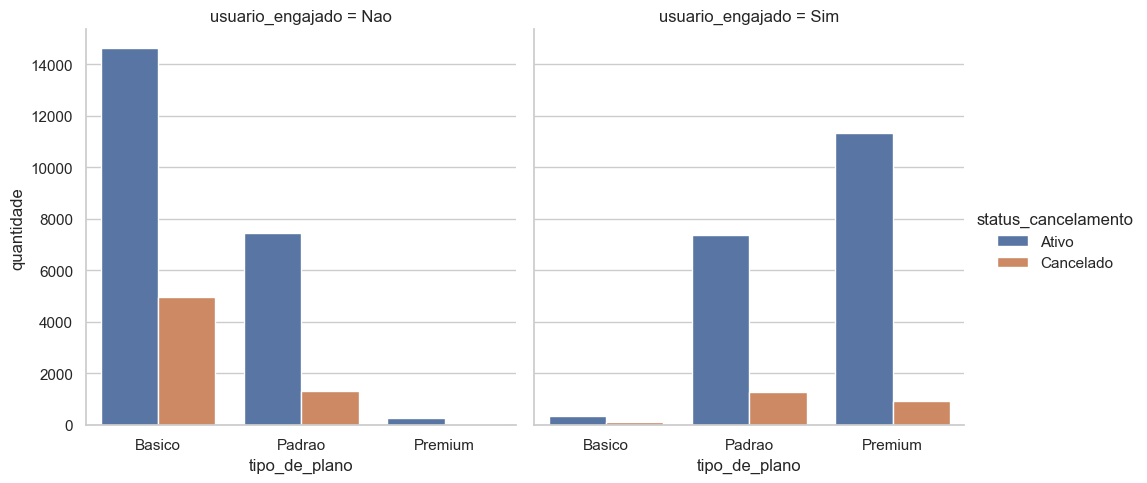

In [59]:
plt.figure(figsize=(12,6))
sns.catplot(
    data=cancelamento_grafico,
    x='tipo_de_plano',
    y='quantidade',
    hue='status_cancelamento',
    col='usuario_engajado',
    kind='bar',
    height=5,
    aspect=1
)

plt.show()

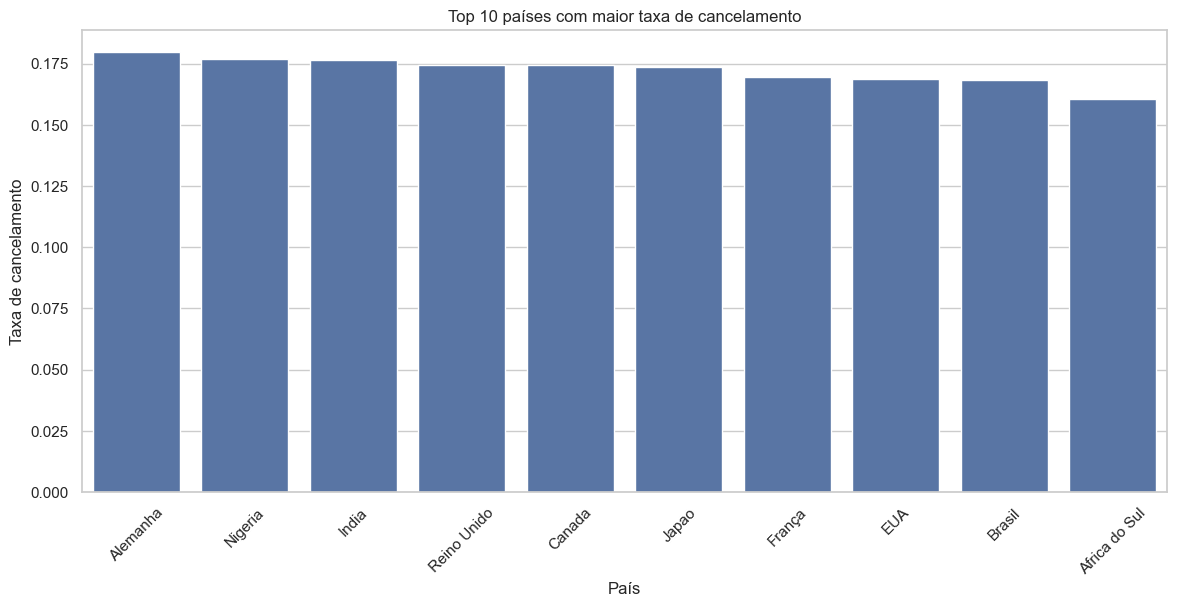

In [60]:
tabela_cancelamento_pais['total_usuarios'] = (
    tabela_cancelamento_pais['usuarios_ativos'] + 
    tabela_cancelamento_pais['usuarios_cancelados']
)

tabela_cancelamento_pais['taxa_cancelamento'] = (
    tabela_cancelamento_pais['usuarios_cancelados'] / 
    tabela_cancelamento_pais['total_usuarios']
)

taxa_paises = tabela_cancelamento_pais.sort_values(
    by='taxa_cancelamento',
    ascending=False
).head(10)

plt.figure(figsize=(14,6))
sns.barplot(
    data=taxa_paises,
    x='país',
    y='taxa_cancelamento'
)

plt.title('Top 10 países com maior taxa de cancelamento')
plt.xlabel('País')
plt.ylabel('Taxa de cancelamento')
plt.xticks(rotation=45)
plt.show()